In [ ]:
import requests
import json
from pathlib import Path
import pandas as pd
from itertools import combinations
import networkx as nx
!pip install GitPython unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 12.1 MB/s eta 0:00:00


In [ ]:
api_key = "irjTGQKkPBoFg4bRlinSRu"

In [ ]:
work_type = "article"
Path("data").mkdir(exist_ok=True)

In [ ]:
filter_string = (
    f"publication_year:2011-2015,"
    f"institutions.country_code:us|gb|ru|it|br|kr,"  # US, UK, Russia, Italy, Brazil, South Korea
    f"primary_topic.field.id:20,"
    f"type:{work_type},"
    f"is_paratext:false")

print(filter_string)

publication_year:2011-2015,institutions.country_code:us|gb|ru|it|br|kr,primary_topic.field.id:20,type:article,is_paratext:false


In [ ]:
url = "https://api.openalex.org/works"

cursor = "*"
all_works = []
downloaded = 0
total = None
page_num = 0

while True:
    params = {
        "filter": filter_string,
        "per_page": 100,
        "cursor": cursor,
        "api_key": api_key}

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    if total is None:
        total = data["meta"]["count"]

    results = data["results"]
    all_works.extend(results)

    downloaded += len(results)
    page_num += 1

    print(f"\rpages: {page_num} | downloaded: {downloaded} / {total}", end="")

    cursor = data["meta"]["next_cursor"]

    if not results or cursor is None:
        break

print()
print("downloaded works num:", len(all_works))

pages: 1453 | downloaded: 145282 / 145282
downloaded works num: 145282


In [ ]:
countries = {"us", "gb", "ru", "it", "br", "kr"}

In [ ]:
rows = []

for work in all_works:
    authorships = work.get("authorships", [])

    if len(authorships) > 15:
        continue

    paper_id = work.get("id")
    paper_title = work.get("display_name")
    publication_year = work.get("publication_year")

    for authorship in authorships:
        author = authorship.get("author", {})
        author_id = author.get("id")
        author_name = author.get("display_name")

        if author_id is None:
            continue

        institutions = authorship.get("institutions", [])

        all_countries = []
        target_countries = []

        for inst in institutions:
            country_code = inst.get("country_code")

            if country_code is None:
                continue

            country_code = country_code.lower()

            if country_code not in all_countries:
                all_countries.append(country_code)

            if country_code in countries and country_code not in target_countries:
                target_countries.append(country_code)

        rows.append({
            "paper_id": paper_id,
            "paper_title": paper_title,
            "publication_year": publication_year,
            "author_id": author_id,
            "author_name": author_name,
            "author_countries_all": ";".join(sorted(all_countries)),
            "author_countries_target": ";".join(sorted(target_countries)),
            "in_target_countries": int(len(target_countries) > 0)})

authors_df = pd.DataFrame(rows)

In [ ]:
paper_sizes = authors_df.groupby("paper_id")["author_id"].nunique()
print(paper_sizes.describe())
print("papers with 1 author:", (paper_sizes == 1).sum())
print("papers with 2+ authors:", (paper_sizes >= 2).sum())

count    143596.000000
mean          2.273246
std           1.621252
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: author_id, dtype: float64
papers with 1 author: 54799
papers with 2+ authors: 88797


In [ ]:
authors_df.to_csv("data/authors_2011_2015.csv", index = False)

In [ ]:
from itertools import combinations

pair_all = []

for paper_id, group in authors_df.groupby("paper_id"):
    group = group.drop_duplicates(subset="author_id").copy()
    group = group.sort_values("author_id")

    authors = group[[
            "author_id",
            "author_name",
            "author_countries_all",
            "author_countries_target",
            "in_target_countries"]].to_dict("records")

    if len(authors) < 2:
        continue

    for a1, a2 in combinations(authors, 2):
        pair_all.append({
            "paper_id": paper_id,

            "author_1_id": a1["author_id"],
            "author_1_name": a1["author_name"],
            "author_1_countries_all": a1["author_countries_all"],
            "author_1_countries_target": a1["author_countries_target"],
            "author_1_in_target": a1["in_target_countries"],

            "author_2_id": a2["author_id"],
            "author_2_name": a2["author_name"],
            "author_2_countries_all": a2["author_countries_all"],
            "author_2_countries_target": a2["author_countries_target"],
            "author_2_in_target": a2["in_target_countries"]})

pairs_df = pd.DataFrame(pair_all)

print("len(pairs_df):", len(pairs_df))
print("unique papers in pairs:", pairs_df["paper_id"].nunique())
pairs_df.head()

len(pairs_df): 396529
unique papers in pairs: 88797


,paper_id,author_1_id,author_1_name,author_1_countries_all,author_1_countries_target,author_1_in_target,author_2_id,author_2_name,author_2_countries_all,author_2_countries_target,author_2_in_target
0,https://openalex.org/W1000130823,https://openalex.org/A5000737419,Alexey Kuznetsov,ru,ru,1,https://openalex.org/A5024715289,E. Khesin,ru,ru,1
1,https://openalex.org/W1000402150,https://openalex.org/A5010768471,E. Fakhrutdinova,ru,ru,1,https://openalex.org/A5024003694,Liliya Safina,ru,ru,1
2,https://openalex.org/W1000402150,https://openalex.org/A5010768471,E. Fakhrutdinova,ru,ru,1,https://openalex.org/A5063495813,А. Ф. Шигабутдинов,ru,ru,1
3,https://openalex.org/W1000402150,https://openalex.org/A5010768471,E. Fakhrutdinova,ru,ru,1,https://openalex.org/A5078851595,R. Fakhrutdinov,ru,ru,1
4,https://openalex.org/W1000402150,https://openalex.org/A5024003694,Liliya Safina,ru,ru,1,https://openalex.org/A5063495813,А. Ф. Шигабутдинов,ru,ru,1


In [ ]:
pairs_df.to_csv("data/pairs_2011_2015.csv", index = False)
print("saved")

saved


In [ ]:
pairs_focal = pairs_df[(pairs_df["author_1_in_target"] == 1) | (pairs_df["author_2_in_target"] == 1)].copy()

edges_df = (pairs_focal.groupby(["author_1_id", "author_2_id"], as_index=False)
    .size().rename(columns={"size": "weight"}))

edges_df = edges_df[edges_df["weight"] <= 15].copy()

print("edges:", len(edges_df))
print("sum weight:", edges_df["weight"].sum())
print("max weight:", edges_df["weight"].max())
edges_df.head()


edges: 266547
sum weight: 334804
max weight: 15


,author_1_id,author_2_id,weight
0,https://openalex.org/A5000000572,https://openalex.org/A5000527699,1
1,https://openalex.org/A5000000572,https://openalex.org/A5007282319,1
2,https://openalex.org/A5000000572,https://openalex.org/A5025396810,1
3,https://openalex.org/A5000000572,https://openalex.org/A5036583884,1
4,https://openalex.org/A5000000572,https://openalex.org/A5038509359,1


In [ ]:
print(len(edges_df))
print(edges_df["weight"].sum())
print(edges_df["weight"].max())
print((edges_df["weight"] == 1).sum())

266547
334804
15
226448


In [ ]:
authors_df = authors_df.drop_duplicates(subset=["paper_id", "author_id"]).copy()

In [ ]:
node_rows = []

for author_id, group in authors_df.groupby("author_id"):
    author_name = group["author_name"].iloc[0]
    num_papers = group["paper_id"].nunique()
    in_target_countries = int(group["in_target_countries"].max())

    all_country_counts = {}
    target_country_counts = {}

    for x in group["author_countries_all"].dropna():
        if x != "":
            for c in x.split(";"):
                all_country_counts[c] = all_country_counts.get(c, 0) + 1

    for x in group["author_countries_target"].dropna():
        if x != "":
            for c in x.split(";"):
                target_country_counts[c] = target_country_counts.get(c, 0) + 1

    all_countries = sorted(all_country_counts.keys())
    target_countries = sorted(target_country_counts.keys())

    main_country_all = max(all_country_counts, key=all_country_counts.get) if all_country_counts else pd.NA
    main_country_target = max(target_country_counts, key=target_country_counts.get) if target_country_counts else pd.NA

    node_rows.append({
        "author_id": author_id,
        "author_name": author_name,
        "author_countries_all": ";".join(all_countries),
        "author_countries_target": ";".join(target_countries),
        "in_target_countries": in_target_countries,
        "main_country_all": main_country_all,
        "main_country_target": main_country_target,
        "num_papers": num_papers})

nodes_df = pd.DataFrame(node_rows)
nodes_df.head()

,author_id,author_name,author_countries_all,author_countries_target,in_target_countries,main_country_all,main_country_target,num_papers
0,https://openalex.org/A5000000572,Piotr Faliszewski,pl;us,us,1,pl,us,12
1,https://openalex.org/A5000001329,Cathy Troupp,gb,gb,1,gb,gb,1
2,https://openalex.org/A5000001782,Nancy Birdsall,us,us,1,us,us,5
3,https://openalex.org/A5000002647,Asif Mujahid,us,us,1,us,us,1
4,https://openalex.org/A5000002920,Roger Kerry,gb,gb,1,gb,gb,1


In [ ]:
print("n of nodes:", len(nodes_df))

n of nodes: 165945


In [ ]:
nodes_df["main_country_target"].value_counts()

,count
main_country_target,
us,78702
gb,22235
it,8872
br,8552
ru,6064
kr,4189


In [ ]:
nodes_df.to_csv("data/nodes_2011_2015.csv", index=False)
print("saved")

saved


In [ ]:
g = nx.Graph()

for _, row in edges_df.iterrows():
    g.add_edge(row["author_1_id"], row["author_2_id"], weight=row["weight"])

print("nodes:", g.number_of_nodes())
print("edges:", g.number_of_edges())

nodes: 139260
edges: 266547


In [ ]:
g.number_of_edges() == len(edges_df)

True

In [ ]:
dup_pairs = edges_df.duplicated(subset=["author_1_id", "author_2_id"]).sum()
print("duplicate pairs by ids only:", dup_pairs)

duplicate pairs by ids only: 0


In [ ]:
paper_sizes = authors_df.groupby("paper_id")["author_id"].nunique()

print(paper_sizes.describe())

print("papers with 1 author in filtered data:", (paper_sizes == 1).sum())
print("papers with 2+ authors in filtered data:", (paper_sizes >= 2).sum())
print("mean team size:", paper_sizes.mean())

count    143596.000000
mean          2.273246
std           1.621252
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: author_id, dtype: float64
papers with 1 author in filtered data: 54799
papers with 2+ authors in filtered data: 88797
mean team size: 2.273245772862754


In [ ]:
print("average degree:", 2 * g.number_of_edges() / g.number_of_nodes())
print("connected components:", nx.number_connected_components(g))

component_sizes = sorted((len(c) for c in nx.connected_components(g)), reverse=True)
print("largest component:", component_sizes[0])
print("top 10 component sizes:", component_sizes[:10])

average degree: 3.8280482550624733
connected components: 18678
largest component: 72250
top 10 component sizes: [72250, 110, 52, 52, 49, 44, 40, 40, 39, 39]


In [ ]:
components = list(nx.connected_components(g))

print("len(components)", len(components))
print("len(max(components))", len(max(components, key=len)))

len(components) 18678
len(max(components)) 72250


In [ ]:
degree_dict = dict(g.degree())
weighted_degree_dict = dict(g.degree(weight="weight"))

In [ ]:
nodes_df["degree"] = nodes_df["author_id"].map(degree_dict).fillna(0).astype(int)
nodes_df["weighted_degree"] = nodes_df["author_id"].map(weighted_degree_dict).fillna(0).astype(int)

nodes_df.head()

,author_id,author_name,author_countries_all,author_countries_target,in_target_countries,main_country_all,main_country_target,num_papers,degree,weighted_degree
0,https://openalex.org/A5000000572,Piotr Faliszewski,pl;us,us,1,pl,us,12,13,23
1,https://openalex.org/A5000001329,Cathy Troupp,gb,gb,1,gb,gb,1,0,0
2,https://openalex.org/A5000001782,Nancy Birdsall,us,us,1,us,us,5,2,4
3,https://openalex.org/A5000002647,Asif Mujahid,us,us,1,us,us,1,9,9
4,https://openalex.org/A5000002920,Roger Kerry,gb,gb,1,gb,gb,1,2,2


In [ ]:
nodes_target = nodes_df[nodes_df["in_target_countries"] == 1].copy()

In [ ]:
largest_component = max(nx.connected_components(g), key=len)
largest_component_set = set(largest_component)

nodes_target["is_in_giant_component"] = nodes_target["author_id"].isin(largest_component_set)

In [ ]:
print(nodes_target[["num_papers", "degree", "weighted_degree"]].describe())

          num_papers         degree  weighted_degree
count  128614.000000  128614.000000    128614.000000
mean        2.137543       3.602501         4.575824
std         3.100659       4.800443         7.548232
min         1.000000       0.000000         0.000000
25%         1.000000       1.000000         1.000000
50%         1.000000       2.000000         2.000000
75%         2.000000       5.000000         6.000000
max       182.000000     142.000000       297.000000


In [ ]:
nodes_target["is_in_giant_component"].value_counts()

,count
is_in_giant_component,
False,75670
True,52944


In [ ]:
nodes_df.to_csv("data/nodes_2011_2015_with_metrics.csv", index=False)
nodes_target.to_csv("data/nodes_target_2011_2015_with_metrics.csv", index=False)
print("saved")

saved


In [ ]:
nodes_target.groupby("main_country_target")[["num_papers", "degree", "weighted_degree"]].mean()

,num_papers,degree,weighted_degree
main_country_target,,,
br,1.605823,2.828695,3.249181
gb,2.292377,3.763796,4.883067
it,2.508566,3.807259,5.180230
kr,1.846025,3.075913,3.668656
ru,1.483179,1.865270,2.140501
us,2.175688,3.779815,4.800971


In [ ]:
nodes_target.groupby("main_country_target")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                     degree                   \
                          mean median       std      mean median       std   
main_country_target                                                          
br                    1.605823    1.0  1.834270  2.828695    2.0  3.073307   
gb                    2.292377    1.0  3.543623  3.763796    2.0  5.224369   
it                    2.508566    1.0  3.510863  3.807259    2.0  4.491784   
kr                    1.846025    1.0  2.225776  3.075913    2.0  3.343509   
ru                    1.483179    1.0  1.691939  1.865270    1.0  2.267052   
us                    2.175688    1.0  3.135706  3.779815    2.0  5.029992   

                    weighted_degree                   
                               mean median       std  
main_country_target                                   
br                         3.249181    2.0  4.072665  
gb                         4.883067    3.0  8.600192  
it                         5.180230    3.0  7.580796  
kr                         3.668656    2.0  4.862240  
ru                         2.140501    1.0  3.067612  
us                         4.800971    3.0  7.819255

In [ ]:
nodes_target.groupby("main_country_target")["is_in_giant_component"].mean()

,is_in_giant_component
main_country_target,
br,0.263798
gb,0.432876
it,0.459310
kr,0.395799
ru,0.084433
us,0.442403


In [ ]:
print((nodes_target["degree"] == 0).sum())

26449


The following code cells as well as this method of extracting gender from name are taken from https://github.com/IES-platform/r4r_gender/tree/main

In [ ]:
import requests
import zipfile
from io import BytesIO
import os
import sys

url = "https://github.com/ClemSternWIPO/gender_it/archive/refs/heads/main.zip"

r = requests.get(url)
r.raise_for_status()

z = zipfile.ZipFile(BytesIO(r.content))
z.extractall("gender_it_local")

print(os.listdir("gender_it_local"))

['gender_it-main']


In [ ]:
sys.path.append("gender_it_local/gender_it-main")
import gender_it_functions as gf

In [ ]:
import re
import numpy as np

def extract_first_name(full_name):
    if pd.isna(full_name):
        return np.nan

    name = str(full_name).strip()
    name = re.sub(r"\s+", " ", name)

    if name == "":
        return np.nan

    first = name.split(" ")[0].strip()
    first_clean = first.replace(".", "")

    if len(first_clean) <= 1:
        return np.nan

    if not re.search(r"[A-Za-zÀ-ÿĀ-žА-Яа-я]", first_clean):
        return np.nan

    return first_clean

In [ ]:
gender_input = (nodes_df[["author_id", "author_name", "main_country_all"]]
    .drop_duplicates(subset=["author_id"])
    .rename(columns={
        "author_name": "name",
        "main_country_all": "country_code"}).copy())

gender_input["first_name"] = gender_input["name"].apply(extract_first_name)
gender_input.head()

,author_id,name,country_code,first_name
0,https://openalex.org/A5000000572,Piotr Faliszewski,pl,Piotr
1,https://openalex.org/A5000001329,Cathy Troupp,gb,Cathy
2,https://openalex.org/A5000001782,Nancy Birdsall,us,Nancy
3,https://openalex.org/A5000002647,Asif Mujahid,us,Asif
4,https://openalex.org/A5000002920,Roger Kerry,gb,Roger


In [ ]:
print("missing first_name:", gender_input["first_name"].isna().sum())

missing first_name: 9118


In [ ]:
gender_input[gender_input["first_name"].isna()]["country_code"].value_counts()

,count
country_code,
us,3329
ru,1525
gb,1066
it,365
br,172
...,...
mn,1
fj,1
al,1


In [ ]:
gender_input[gender_input["first_name"].isna()].sample(30)[["name", "country_code"]]

,name,country_code
126271,W. David Ball,us
18279,D. Kurowski,us
28656,A. Marshall McBean,us
65259,J. Doyne Farmer,gb
121386,N Rishika,gb
2082,V. Sonathi,in
40006,I. Gordeyeva,<NA>
145732,A. Mukhopadhyay,in
105262,E. A Vinogradova,ru
89422,A. J. M. Garrett,gb


In [ ]:
dict_path = "gender_it_local/gender_it-main/dictionaries/"

In [ ]:
d2_1 = pd.read_csv(dict_path + "d2_1.csv.gz", compression="gzip")
d2_2 = pd.read_csv(dict_path + "d2_2.csv.gz", compression="gzip")
d2_3 = pd.read_csv(dict_path + "d2_3.csv.gz", compression="gzip")

d2 = pd.concat([d2_1, d2_2, d2_3], ignore_index=True)

d2.to_csv(dict_path + "d2.csv.gz", index=False, compression="gzip")

print("saved:", dict_path + "d2.csv.gz")
print(d2.shape)

saved: gender_it_local/gender_it-main/dictionaries/d2.csv.gz
(26043223, 3)


In [ ]:
import os
print(os.listdir(dict_path))

['d2_3.csv.gz', 'd3.csv.gz', 'd2_1.csv.gz', 'd1.csv.gz', 'Data description', 'd2_2.csv.gz', 'd2.csv.gz']


In [ ]:
gender_work = gender_input.dropna(subset=["first_name", "country_code"])[["author_id", "first_name", "country_code"]].copy()
gender_work = gender_work.rename(columns={"first_name": "name"})

gendered_nodes = gf.get_gender(gender_work, name_column="name", country_column="country_code", threshold=0.75, path=dict_path)

Step 1 - Reading the name-country-gender dictionary
reading the dictionnary.
Step 2 - Reading the name-language-gender dictionary
reading the dictionnary.
Step 3 - Reading the name-gender dictionary
reading the dictionnary.
dff        name_id clean_name  surname_position clean_country_column
18839    18839    chaolin                 2                   CN
Results distribution is as follows:
            count  Percentage
gender                      
M          86754   60.273877
F          42256   29.358104
not found  14008    9.732306
?            915    0.635712


In [ ]:
print(gendered_nodes.columns.tolist())
gendered_nodes.head()

['level', 'gender', '?', 'F', 'M', 'author_id', 'name', 'country_code']


,level,gender,?,F,M,author_id,name,country_code
0,1,M,0.0,0.000000,1.0,https://openalex.org/A5000000572,Piotr,pl
1,1,F,0.0,1.000000,0.0,https://openalex.org/A5000001329,Cathy,gb
2,1,F,0.0,0.997062,0.0,https://openalex.org/A5000001782,Nancy,us
3,1,M,0.0,0.000000,1.0,https://openalex.org/A5000002647,Asif,us
4,1,M,0.0,0.000000,1.0,https://openalex.org/A5000002920,Roger,gb


In [ ]:
gendered_nodes["name_inferred_gender"] = gendered_nodes["gender"].replace({"F": "female", "M": "male", "?": "unknown", "not found": "unknown"})

In [ ]:
nodes_df = nodes_df.merge(gendered_nodes[["author_id", "gender",
                                          "name_inferred_gender", "F", "M", "level"]],
                          on="author_id", how="left")

nodes_df["name_inferred_gender"] = nodes_df["name_inferred_gender"].fillna("unknown")
nodes_df["gender"] = nodes_df["gender"].fillna("not found")

In [ ]:
nodes_target = nodes_df[nodes_df["in_target_countries"] == 1].copy()

In [ ]:
nodes_df["name_inferred_gender"].value_counts(dropna=False)

,count
name_inferred_gender,
male,86754
female,42256
unknown,36935


In [ ]:
pd.crosstab(nodes_df["level"], nodes_df["name_inferred_gender"], dropna=False)

name_inferred_gender,female,male,unknown
level,,,
1.0,34948,35996,915
2.0,3406,43566,0
3.0,3902,7192,14008
NaN,0,0,22012


In [ ]:
nodes_df.to_csv("data/nodes_2011_2015_with_gender.csv", index=False)
nodes_target.to_csv("data/nodes_target_2011_2015_with_gender.csv", index=False)
print("saved")

saved


In [ ]:
pd.crosstab(nodes_df["main_country_target"], nodes_df["name_inferred_gender"])

name_inferred_gender,female,male,unknown
main_country_target,,,
br,2475,5047,1030
gb,6487,13490,2258
it,2875,5425,572
kr,489,876,2824
ru,1572,1924,2568
us,22870,46641,9191


In [ ]:
pd.crosstab(nodes_df["main_country_target"], nodes_df["name_inferred_gender"], normalize="index")

name_inferred_gender,female,male,unknown
main_country_target,,,
br,0.289406,0.590154,0.120440
gb,0.291747,0.606701,0.101552
it,0.324053,0.611474,0.064472
kr,0.116734,0.209119,0.674147
ru,0.259235,0.317282,0.423483
us,0.290590,0.592628,0.116782


In [ ]:
analysis_df = nodes_df[nodes_df["name_inferred_gender"].isin(["female", "male"])].copy()

analysis_df.groupby("name_inferred_gender")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                     degree                   \
                           mean median       std      mean median       std   
name_inferred_gender                                                          
female                 1.724489    1.0  1.984227  3.434353    2.0  4.283902   
male                   2.278638    1.0  3.378804  3.389780    2.0  4.789291   

                     weighted_degree                   
                                mean median       std  
name_inferred_gender                                   
female                      4.154795    2.0  6.341761  
male                        4.427565    2.0  7.708950

In [ ]:
analysis_df = nodes_target[nodes_target["name_inferred_gender"].isin(["female", "male"])].copy()

analysis_df.groupby("name_inferred_gender")[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                    degree                   \
                           mean median       std     mean median       std   
name_inferred_gender                                                         
female                 1.773363    1.0  2.083917  3.66460    2.0  4.503704   
male                   2.394398    1.0  3.599845  3.64966    2.0  5.105637   

                     weighted_degree                   
                                mean median       std  
name_inferred_gender                                   
female                      4.444816    3.0  6.699029  
male                        4.785145    2.0  8.239265

In [ ]:
analysis_df.groupby(["main_country_target", "name_inferred_gender"])[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                   \
                                               mean median       std   
main_country_target name_inferred_gender                               
br                  female                 1.342626    1.0  1.037972   
                    male                   1.756291    1.0  2.183707   
gb                  female                 1.843996    1.0  2.281126   
                    male                   2.565085    1.0  4.095615   
it                  female                 2.113739    1.0  2.457276   
                    male                   2.826544    1.0  4.055837   
kr                  female                 1.603272    1.0  1.566186   
                    male                   1.892694    1.0  2.414696   
ru                  female                 1.391221    1.0  1.159578   
                    male                   1.755198    1.0  2.560927   
us                  female                 1.787057    1.0  2.106909   
                    male                   2.399605    1.0  3.555111   

                                            degree                   \
                                              mean median       std   
main_country_target name_inferred_gender                              
br                  female                2.875960    2.0  2.989399   
                    male                  2.744997    2.0  3.086377   
gb                  female                3.724988    2.0  4.953210   
                    male                  3.813269    2.0  5.517766   
it                  female                3.522435    2.0  4.020619   
                    male                  3.943779    3.0  4.787710   
kr                  female                2.946830    2.0  3.073091   
                    male                  3.038813    2.0  3.543796   
ru                  female                2.076972    1.0  2.135107   
                    male                  1.872661    1.0  2.457523   
us                  female                3.875164    3.0  4.673243   
                    male                  3.750799    2.0  5.271136   

                                         weighted_degree                   
                                                    mean median       std  
main_country_target name_inferred_gender                                   
br                  female                      3.203636    2.0  3.666326  
                    male                        3.205865    2.0  4.245282  
gb                  female                      4.562664    3.0  7.606316  
                    male                        5.122165    3.0  9.364865  
it                  female                      4.659130    3.0  6.691844  
                    male                        5.521843    3.0  8.196513  
kr                  female                      3.441718    2.0  4.013958  
                    male                        3.634703    2.0  5.122176  
ru                  female                      2.324427    2.0  2.703528  
                    male                        2.292100    1.0  3.668806  
us                  female                      4.685964    3.0  6.873712  
                    male                        4.897322    2.0  8.366838

In [ ]:
strict_df = nodes_df[(nodes_df["name_inferred_gender"].isin(["female", "male"])) & (nodes_df["level"].isin([1, 2]))].copy()

In [ ]:
strict_df.groupby(["main_country_target", "name_inferred_gender"])[["num_papers", "degree", "weighted_degree"]].agg(["mean", "median", "std"])

num_papers                   \
                                               mean median       std   
main_country_target name_inferred_gender                               
br                  female                 1.329169    1.0  0.997349   
                    male                   1.799154    1.0  2.246172   
gb                  female                 1.823709    1.0  2.241738   
                    male                   2.573636    1.0  4.124233   
it                  female                 2.119561    1.0  2.468886   
                    male                   2.838202    1.0  4.067887   
kr                  female                 1.619608    1.0  1.425446   
                    male                   1.927632    1.0  2.743469   
ru                  female                 1.418960    1.0  1.197552   
                    male                   1.861091    1.0  2.890086   
us                  female                 1.779351    1.0  2.093295   
                    male                   2.406524    1.0  3.561809   

                                            degree                   \
                                              mean median       std   
main_country_target name_inferred_gender                              
br                  female                2.873829    2.0  3.034233   
                    male                  2.761324    2.0  3.095047   
gb                  female                3.721206    2.0  4.935936   
                    male                  3.830783    2.0  5.580300   
it                  female                3.529890    2.0  4.033925   
                    male                  3.954494    3.0  4.730377   
kr                  female                3.298039    2.0  3.114197   
                    male                  3.440789    2.0  4.048715   
ru                  female                2.159786    2.0  2.173008   
                    male                  2.037091    1.0  2.564894   
us                  female                3.898414    3.0  4.702676   
                    male                  3.761414    2.0  5.309071   

                                         weighted_degree                   
                                                    mean median       std  
main_country_target name_inferred_gender                                   
br                  female                      3.186758    2.0  3.664625  
                    male                        3.243654    2.0  4.308621  
gb                  female                      4.530959    3.0  7.510007  
                    male                        5.152681    3.0  9.488268  
it                  female                      4.669968    3.0  6.702058  
                    male                        5.541386    3.0  8.147680  
kr                  female                      3.815686    2.0  4.051993  
                    male                        4.103070    2.0  5.944460  
ru                  female                      2.424312    2.0  2.741267  
                    male                        2.531636    1.0  3.919530  
us                  female                      4.703080    3.0  6.871807  
                    male                        4.911787    2.0  8.383992

### Gender composition of edges

In [ ]:
edge_gender_df = edges_df.copy()

gender_smth = (nodes_df[["author_id", "name_inferred_gender"]].drop_duplicates(subset=["author_id"])
    .rename(columns={"name_inferred_gender": "gender"}))

edge_gender_df = edge_gender_df.merge(gender_smth.rename(columns={"author_id": "author_1_id", "gender": "gender_1"}),
    on="author_1_id", how="left")

edge_gender_df = edge_gender_df.merge(gender_smth.rename(columns={"author_id": "author_2_id", "gender": "gender_2"}),
    on="author_2_id", how="left")

edge_gender_df[["author_1_id", "gender_1", "author_2_id", "gender_2", "weight"]].head()

,author_1_id,gender_1,author_2_id,gender_2,weight
0,https://openalex.org/A5000000572,male,https://openalex.org/A5000527699,female,1
1,https://openalex.org/A5000000572,male,https://openalex.org/A5007282319,male,1
2,https://openalex.org/A5000000572,male,https://openalex.org/A5025396810,male,1
3,https://openalex.org/A5000000572,male,https://openalex.org/A5036583884,male,1
4,https://openalex.org/A5000000572,male,https://openalex.org/A5038509359,male,1


In [ ]:
def edge_gender(g1, g2):
    if pd.isna(g1) or pd.isna(g2):
        return "unknown"

    if g1 == "unknown" or g2 == "unknown":
        return "unknown"

    if g1 == "female" and g2 == "female":
        return "female-female"
    if g1 == "male" and g2 == "male":
        return "male-male"

    if {g1, g2} == {"female", "male"}:
        return "female-male"

    return "unknown"


edge_gender_df["edge_gender_type"] = edge_gender_df.apply(lambda row: edge_gender(row["gender_1"], row["gender_2"]),axis=1)

In [ ]:
edge_gender_counts = edge_gender_df["edge_gender_type"].value_counts().rename_axis("edge_gender_type").reset_index(name="num_edges")
edge_gender_counts

,edge_gender_type,num_edges
0,male-male,88401
1,unknown,80525
2,female-male,72053
3,female-female,25568


In [ ]:
print(nodes_df["name_inferred_gender"].value_counts(dropna=False))
(nodes_df["name_inferred_gender"] == "unknown").mean()
print((edge_gender_df["gender_1"] == "unknown").mean())
print((edge_gender_df["gender_2"] == "unknown").mean())
print((edge_gender_df["edge_gender_type"] == "unknown").mean())

name_inferred_gender
male       86754
female     42256
unknown    36935
Name: count, dtype: int64
0.16954233212153955
0.18272199649592755
0.30210431931329185


In [ ]:
c_edge_gender_df = edge_gender_df[edge_gender_df["edge_gender_type"] != "unknown"].copy()

In [ ]:
c_edge_stats = (c_edge_gender_df.groupby("edge_gender_type", as_index=False)
                .agg(num_edges=("weight", "size"),total_weight=("weight", "sum")))

c_edge_stats["share_edges"] = c_edge_stats["num_edges"] / c_edge_stats["num_edges"].sum()
c_edge_stats["share_weight"] = c_edge_stats["total_weight"] / c_edge_stats["total_weight"].sum()

c_edge_stats = c_edge_stats.sort_values("num_edges", ascending=False)
c_edge_stats

,edge_gender_type,num_edges,total_weight,share_edges,share_weight
2,male-male,88401,119839,0.475218,0.498675
1,female-male,72053,90269,0.387336,0.375628
0,female-female,25568,30207,0.137446,0.125698


In [ ]:
edge_gender_df.to_csv("data/edges_2011_2015_with_gender.csv", index=False)
c_edge_stats.to_csv("data/edge_gender_stats_2011_2015_without_NaN.csv", index=False)

### By country

In [ ]:
edge_country_df = c_edge_gender_df.copy()
country_lookup = nodes_df[["author_id", "main_country_target"]].copy()

In [ ]:
edge_country_df = edge_country_df.merge(country_lookup.rename(columns={"author_id": "author_1_id", "main_country_target": "country_1"}),
                                        on="author_1_id",how="left")

In [ ]:
edge_country_df = edge_country_df.merge(country_lookup.rename(columns={"author_id": "author_2_id", "main_country_target": "country_2"}),
                                        on="author_2_id",how="left")

In [ ]:
within_country_edges = edge_country_df[edge_country_df["country_1"] == edge_country_df["country_2"]].copy()
within_country_edges["country"] = within_country_edges["country_1"]

In [ ]:
country_edge_stats = (within_country_edges.groupby(["country", "edge_gender_type"], as_index=False)
                             .agg(num_edges=("weight", "size"),total_weight=("weight", "sum")))

In [ ]:
country_edge_stats["share_edges"] = (country_edge_stats["num_edges"] / country_edge_stats.groupby("country")["num_edges"].transform("sum"))

country_edge_stats["share_weight"] = (country_edge_stats["total_weight"] / country_edge_stats.groupby("country")["total_weight"].transform("sum"))

country_edge_stats = country_edge_stats.sort_values(["country", "num_edges"], ascending=[True, False])

country_edge_table = country_edge_stats.pivot(index="country", columns="edge_gender_type",values="share_edges").fillna(0)

country_edge_table

edge_gender_type,female-female,female-male,male-male
country,,,
br,0.157614,0.375520,0.466866
gb,0.149243,0.397444,0.453312
it,0.139985,0.398722,0.461293
kr,0.158879,0.463551,0.377570
ru,0.343367,0.382653,0.273980
us,0.149798,0.398573,0.451629


### gender assortativity

In [ ]:
gender_attr = nodes_df.set_index("author_id")["name_inferred_gender"].to_dict()
country_attr = nodes_df.set_index("author_id")["main_country_target"].to_dict()

nx.set_node_attributes(g, gender_attr, "gender")
nx.set_node_attributes(g, country_attr, "country")

In [ ]:
classified_nodes = [n for n, d in g.nodes(data=True)
                    if d.get("gender") in ["female", "male"]]

g_classified = g.subgraph(classified_nodes).copy()

In [ ]:
overall_gender_assortativity = nx.attribute_assortativity_coefficient(g_classified, "gender")
overall_gender_assortativity

0.12556391331663067

In [ ]:
country_assort_rows = []

for country in sorted(nodes_df["main_country_target"].dropna().unique()):
    country_nodes = [n for n, d in g_classified.nodes(data=True)
                     if d.get("country") == country]

    subg = g_classified.subgraph(country_nodes).copy()

    if subg.number_of_edges() == 0:
        assort = float("nan")
    else:
        assort = nx.attribute_assortativity_coefficient(subg, "gender")

    country_assort_rows.append({"country": country,
                                "num_nodes": subg.number_of_nodes(),
                                "num_edges": subg.number_of_edges(),
                                "gender_assortativity": assort})

country_assort_df = pd.DataFrame(country_assort_rows)

In [ ]:
country_assort_df

,country,num_nodes,num_edges,gender_assortativity
0,br,6092,7696,0.169538
1,gb,15546,22929,0.124130
2,it,6870,10644,0.110750
3,kr,1151,535,0.026330
4,ru,2475,1960,0.230991
5,us,54916,97558,0.122953


In [ ]:
ru_nodes = [n for n, d in g_classified.nodes(data=True) if d.get("country") == "ru"]
g_ru = g_classified.subgraph(ru_nodes).copy()

print("nodes:", g_ru.number_of_nodes())
print("edges:", g_ru.number_of_edges())
print("isolates:", nx.number_of_isolates(g_ru))

nodes: 2475
edges: 1960
isolates: 678


In [ ]:
ru_nodes = [n for n, d in g_classified.nodes(data=True) if d.get("country") == "ru"]
g_ru = g_classified.subgraph(ru_nodes).copy()

ru_isolates = list(nx.isolates(g_ru))

country_counts = {}

for node in ru_isolates:
    for nbr in g_classified.neighbors(node):
        c = g_classified.nodes[nbr].get("country", "NA")
        country_counts[c] = country_counts.get(c, 0) + 1

country_counts_df = (
    pd.DataFrame(country_counts.items(), columns=["neighbor_country", "num_links"])
    .sort_values("num_links", ascending=False)
    .reset_index(drop=True))

country_counts_df

,neighbor_country,num_links
0,None,298
1,us,192
2,gb,107
3,it,40
4,br,8
5,kr,2


In [ ]:
nodes_df.to_csv("data/nodes_2024_final.csv", index=False)
edges_df.to_csv("data/edges_2024.csv", index=False)
edge_gender_df.to_csv("data/edges_2024_with_gender.csv", index=False)
c_edge_stats.to_csv("data/edge_gender_stats_2024_classified.csv", index=False)
country_edge_stats.to_csv("data/country_edge_stats_2024.csv", index=False)
country_edge_table.to_csv("data/country_edge_share_table_2024.csv")
obs_exp_country.to_csv("data/obs_exp_country_2024.csv")
country_assort_df.to_csv("data/country_gender_assortativity_2024.csv", index=False)

RANDOM MODEL

In [ ]:
obs_assort = nx.attribute_assortativity_coefficient(g_classified, "gender")
print(obs_assort)

0.12556391331663067


In [ ]:
g_rand = g_classified.copy()

nx.double_edge_swap(g_rand,
    nswap=10 * g_rand.number_of_edges(),
    max_tries=100 * g_rand.number_of_edges())

rand_assort = nx.attribute_assortativity_coefficient(g_rand, "gender")
print(rand_assort)

0.0011697883183026483


In [ ]:
B = 100
null_vals = []

nodes = list(g_classified.nodes())
genders = np.array([g_classified.nodes[n]["gender"] for n in nodes])

for _ in range(B):
    shuffled = np.random.permutation(genders)

    g_rand = g_classified.copy()
    nx.set_node_attributes(g_rand,
        {n: shuffled[i] for i, n in enumerate(nodes)},
        "gender")

    val = nx.attribute_assortativity_coefficient(g_rand, "gender")
    null_vals.append(val)

null_vals = np.array(null_vals)

print("observed:", obs_assort)
print("null mean:", null_vals.mean())
print("null std:", null_vals.std(ddof=1))
print("z-score:", (obs_assort - null_vals.mean()) / null_vals.std(ddof=1))

observed: 0.12556391331663067
null mean: -0.00034900079492523585
null std: 0.002272924936042807
z-score: 55.39686424082793


In [ ]:
def edge_type(g1, g2):
    if g1 == "female" and g2 == "female":
        return "female-female"
    elif g1 == "male" and g2 == "male":
        return "male-male"
    else:
        return "female-male"

obs_counts = {"female-female": 0, "male-male": 0, "female-male": 0}

for u, v in g_classified.edges():
    t = edge_type(g_classified.nodes[u]["gender"], g_classified.nodes[v]["gender"])
    obs_counts[t] += 1

obs_counts

{'female-female': 25568, 'male-male': 88401, 'female-male': 72053}

In [ ]:

B = 100
nodes = list(g_classified.nodes())
genders = np.array([g_classified.nodes[n]["gender"] for n in nodes])

null_results = []

for _ in range(B):
    shuffled = np.random.permutation(genders)

    g_rand = g_classified.copy()
    nx.set_node_attributes(g_rand,
        {n: shuffled[i] for i, n in enumerate(nodes)},
        "gender")

    rand_counts = {"female-female": 0, "male-male": 0, "female-male": 0}

    for u, v in g_rand.edges():
        t = edge_type(g_rand.nodes[u]["gender"], g_rand.nodes[v]["gender"])
        rand_counts[t] += 1

    null_results.append(rand_counts)

null_df = pd.DataFrame(null_results)

result_df = pd.DataFrame({
    "edge_type": ["female-female", "female-male", "male-male"],
    "observed": [obs_counts["female-female"],
        obs_counts["female-male"],
        obs_counts["male-male"]],
    "random_mean": [null_df["female-female"].mean(),
        null_df["female-male"].mean(),
        null_df["male-male"].mean()],
    "random_sd": [null_df["female-female"].std(ddof=1),
        null_df["female-male"].std(ddof=1),
        null_df["male-male"].std(ddof=1)]})

result_df["difference"] = result_df["observed"] - result_df["random_mean"]
result_df["pct_diff"] = 100 * result_df["difference"] / result_df["random_mean"]

result_df.round(2)

,edge_type,observed,random_mean,random_sd,difference,pct_diff
0,female-female,25568,20015.80,245.41,5552.20,27.74
1,female-male,72053,82015.87,261.54,-9962.87,-12.15
2,male-male,88401,83990.33,403.06,4410.67,5.25


BY YEAR


In [ ]:
import matplotlib.pyplot as plt


gender_lookup = nx.get_node_attributes(g_classified, "gender")

paper_year = authors_df[["paper_id", "publication_year"]].drop_duplicates()

pairs_year_df = pairs_df.merge(paper_year, on="paper_id", how="left")


pairs_year_df = pairs_year_df[pairs_year_df["author_1_id"].isin(gender_lookup.keys()) &
    pairs_year_df["author_2_id"].isin(gender_lookup.keys())].copy()

pairs_year_df["gender_1"] = pairs_year_df["author_1_id"].map(gender_lookup)
pairs_year_df["gender_2"] = pairs_year_df["author_2_id"].map(gender_lookup)

pairs_year_df = pairs_year_df[pairs_year_df["gender_1"].isin(["female", "male"]) &
    pairs_year_df["gender_2"].isin(["female", "male"])].copy()




In [ ]:

def yearly_gender_bias(df_year, B=50, seed=42):

    edges_year = (df_year.groupby(["author_1_id", "author_2_id"], as_index=False)
        .size().rename(columns={"size": "weight"}))

    G_year = nx.Graph()

    for _, row in edges_year.iterrows():
        G_year.add_edge(row["author_1_id"],row["author_2_id"],weight=row["weight"])


    nx.set_node_attributes(G_year,
        {n: gender_lookup[n] for n in G_year.nodes() if n in gender_lookup},
        "gender")

    keep_nodes = [n for n, d in G_year.nodes(data=True)
        if d.get("gender") in ["female", "male"]]
    G_year = G_year.subgraph(keep_nodes).copy()

    if G_year.number_of_edges() == 0:
        return {
            "num_nodes": G_year.number_of_nodes(),
            "num_edges": G_year.number_of_edges(),
            "female_share": np.nan,
            "assortativity": np.nan,
            "same_gender_share_obs": np.nan,
            "same_gender_share_null": np.nan,
            "same_gender_excess_pp": np.nan,
            "assortativity_z": np.nan}

    genders = np.array([G_year.nodes[n]["gender"] for n in G_year.nodes()])
    female_share = (genders == "female").mean()

    assort_obs = nx.attribute_assortativity_coefficient(G_year, "gender")

    same_obs = sum(1 for u, v in G_year.edges()
        if G_year.nodes[u]["gender"] == G_year.nodes[v]["gender"]) / G_year.number_of_edges()

    rng = np.random.default_rng(seed)
    nodes = list(G_year.nodes())

    assort_null = []
    same_null = []

    for _ in range(B):
        shuffled = rng.permutation(genders)

        G_rand = G_year.copy()
        nx.set_node_attributes(G_rand,
            {node: shuffled[i] for i, node in enumerate(nodes)},
            "gender")

        assort_null.append(nx.attribute_assortativity_coefficient(G_rand, "gender"))

        same_null.append(sum(
                1 for u, v in G_rand.edges()
                if G_rand.nodes[u]["gender"] == G_rand.nodes[v]["gender"]) / G_rand.number_of_edges())

    assort_null = np.array(assort_null)
    same_null = np.array(same_null)

    assort_sd = assort_null.std(ddof=1)

    return {
        "num_nodes": G_year.number_of_nodes(),
        "num_edges": G_year.number_of_edges(),
        "female_share": female_share,
        "assortativity": assort_obs,
        "same_gender_share_obs": same_obs,
        "same_gender_share_null": same_null.mean(),
        "same_gender_excess_pp": 100 * (same_obs - same_null.mean()),
        "assortativity_z": np.nan if assort_sd == 0 else (assort_obs - assort_null.mean()) / assort_sd}




In [ ]:
results = []

for year in range(2011, 2016):
    df_year = pairs_year_df[pairs_year_df["publication_year"] == year].copy()
    stats = yearly_gender_bias(df_year, B=100, seed=year)
    stats["year"] = year
    results.append(stats)

bias_by_year = pd.DataFrame(results).sort_values("year").reset_index(drop=True)


bias_table = bias_by_year.copy()

bias_table["female_share_pct"] = 100 * bias_table["female_share"]
bias_table["same_gender_share_obs_pct"] = 100 * bias_table["same_gender_share_obs"]
bias_table["same_gender_share_null_pct"] = 100 * bias_table["same_gender_share_null"]

bias_table = bias_table[[
        "year",
        "num_nodes",
        "num_edges",
        "female_share_pct",
        "assortativity",
        "assortativity_z",
        "same_gender_share_obs_pct",
        "same_gender_share_null_pct",
        "same_gender_excess_pp"]].round(3)

bias_table

,year,num_nodes,num_edges,female_share_pct,assortativity,assortativity_z,same_gender_share_obs_pct,same_gender_share_null_pct,same_gender_excess_pp
0,2011,26250,37709,27.444,0.114,23.677,63.725,60.192,3.533
1,2012,28430,44213,28.867,0.121,28.372,62.473,58.921,3.551
2,2013,29876,49034,29.492,0.118,27.597,61.992,58.409,3.582
3,2014,31732,52222,31.107,0.124,27.582,61.068,57.126,3.942
4,2015,33689,56673,31.601,0.130,30.135,60.950,56.782,4.167


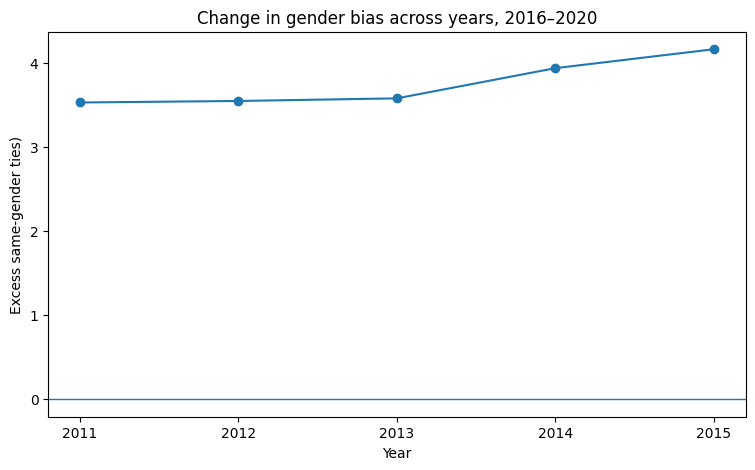

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(bias_by_year["year"],bias_by_year["same_gender_excess_pp"],marker="o")


plt.axhline(0, linewidth=1)

plt.xticks(bias_by_year["year"])
plt.xlabel("Year")
plt.ylabel("Excess same-gender ties)")
plt.title("Change in gender bias across years, 2016–2020")
plt.show()

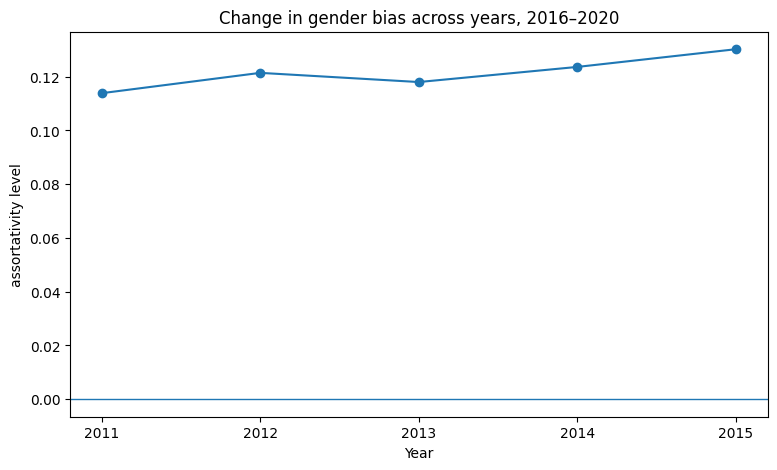

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(bias_by_year["year"],bias_by_year["assortativity"],marker="o")


plt.axhline(0, linewidth=1)

plt.xticks(bias_by_year["year"])
plt.xlabel("Year")
plt.ylabel("assortativity level")
plt.title("Change in gender bias across years, 2016–2020")
plt.show()